<a href="https://colab.research.google.com/github/rhonaeloisa/HEAKACORO/blob/main/HEAKACORA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import *
from pyspark.sql.functions import *
import matplotlib.pyplot as plt
from pyspark.ml.feature import StringIndexer, OneHotEncoder
from pyspark.sql.functions import col, max as spark_max
from pyspark.sql.window import Window
from pyspark.sql.functions import row_number
from pyspark.sql.types import DoubleType
import seaborn as sns
import pandas as pd

spark = SparkSession.builder.appName('HEAKACORO').getOrCreate()

In [ ]:
schema1 = StructType([
    StructField("student_id", IntegerType(), True),
    StructField("development_level", StringType(), True),
    StructField("poverty_rate_percent", DoubleType(), True),
    StructField("internet_infrastructure_index", DoubleType(), True),
    StructField("average_internet_speed_mbps", DoubleType(), True),
    StructField("age", IntegerType(), True),
    StructField("gender", StringType(), True),
    StructField("urban_rural", StringType(), True),
    StructField("family_income_level", StringType(), True),
    StructField("device_access", StringType(), True),
    StructField("internet_access_hours", DoubleType(), True),
    StructField("education_level", StringType(), True),
    StructField("field_of_study", StringType(), True),
    StructField("academic_motivation", DoubleType(), True),
    StructField("online_learning_hours", DoubleType(), True),
    StructField("social_media_hours", DoubleType(), True),
    StructField("sessions_per_day", DoubleType(), True),
    StructField("average_session_length_minutes", DoubleType(), True),
    StructField("late_night_usage", StringType(), True),
    StructField("education_content_hours", DoubleType(), True),
    StructField("short_video_hours", DoubleType(), True),
    StructField("entertainment_content_hours", DoubleType(), True),
    StructField("news_content_hours", DoubleType(), True),
    StructField("likes_given_per_day", DoubleType(), True),
    StructField("comments_written_per_day", DoubleType(), True),
    StructField("posts_created_per_week", DoubleType(), True),
    StructField("late_night_score", IntegerType(), True),
    StructField("brain_rot_index", DoubleType(), True),
    StructField("brain_rot_level", StringType(), True),
    StructField("attention_span_minutes", DoubleType(), True),
    StructField("study_hours_per_week", DoubleType(), True),
    StructField("class_attendance_rate", DoubleType(), True),
    StructField("productivity_score", DoubleType(), True),
    StructField("sleep_hours", DoubleType(), True),
    StructField("stress_level", StringType(), True),
    StructField("anxiety_score", DoubleType(), True),
    StructField("depression_score", DoubleType(), True),
    StructField("ads_viewed_per_day", DoubleType(), True),
    StructField("ads_clicked_per_week", DoubleType(), True),
    StructField("impulse_purchase_score", DoubleType(), True),
    StructField("digital_spending_per_month", DoubleType(), True),
    StructField("cyberbullying_exposure", StringType(), True),
    StructField("adult_content_exposure", StringType(), True),
    StructField("digital_addiction_score", DoubleType(), True),
    StructField("wellbeing_index", DoubleType(), True),
    StructField("academic_risk_score", DoubleType(), True),
])

schema2 = StructType([
    StructField("Age", DoubleType(), True),
    StructField("Gender", StringType(), True),
    StructField("Previous_Grades", StringType(), True),
    StructField("Attendance", StringType(), True),
    StructField("Class_Participation", StringType(), True),
    StructField("Study_Hours", StringType(), True),
    StructField("Major", StringType(), True),
    StructField("School_Type", StringType(), True),
    StructField("Educational_Resources", StringType(), True),
    StructField("Motivation", StringType(), True),
    StructField("Self_Esteem", StringType(), True),
    StructField("Stress_Levels", StringType(), True),
    StructField("School_Environment", StringType(), True),
    StructField("Professor_Quality", StringType(), True),
    StructField("Class_Size", DoubleType(), True),
    StructField("Extracurricular_Activities", StringType(), True),
    StructField("Sleep_Patterns", DoubleType(), True),
    StructField("Nutrition", StringType(), True),
    StructField("Physical_Activity", StringType(), True),
    StructField("Screen_Time", DoubleType(), True),
    StructField("Educational_Tech_Use", StringType(), True),
    StructField("Peer_Group", StringType(), True),
    StructField("Bullying", StringType(), True),
    StructField("Study_Space", StringType(), True),
    StructField("Learning_Style", StringType(), True),
    StructField("Tutoring", StringType(), True),
    StructField("Mentoring", StringType(), True),
    StructField("Lack_of_Interest", StringType(), True),
    StructField("Time_Wasted_on_Social_Media", DoubleType(), True),
    StructField("Sports_Participation", StringType(), True),
    StructField("Grades", StringType(), True)
])

schema3 = StructType([
    StructField("transaction_id", StringType(), True),
    StructField("user_id", StringType(), True),
    StructField("age", IntegerType(), True),
    StructField("gender", StringType(), True),
    StructField("daily_screen_time_hours", DoubleType(), True),
    StructField("social_media_hours", DoubleType(), True),
    StructField("gaming_hours", DoubleType(), True),
    StructField("work_study_hours", DoubleType(), True),
    StructField("sleep_hours", DoubleType(), True),
    StructField("notifications_per_day", IntegerType(), True),
    StructField("app_opens_per_day", IntegerType(), True),
    StructField("weekend_screen_time", DoubleType(), True),
    StructField("stress_level", StringType(), True),
    StructField("academic_work_impact", StringType(), True),
    StructField("addiction_level", StringType(), True),
    StructField("addicted_label", IntegerType(), True)
])

df1 = spark.read.csv('/content/global_student_digital_behavior_dataset.csv', schema=schema1, header=True)
df2 = spark.read.csv('/content/Factors_ affecting_ university_student_grades_dataset.csv', schema=schema2, header=True)
df3 = spark.read.csv('/content/Smartphone_Usage_And_Addiction_Analysis_7500_Rows.csv', schema=schema3, header=True)

df1.printSchema()
df2.printSchema()
df3.printSchema()

root
 |-- student_id: integer (nullable = true)
 |-- development_level: string (nullable = true)
 |-- poverty_rate_percent: double (nullable = true)
 |-- internet_infrastructure_index: double (nullable = true)
 |-- average_internet_speed_mbps: double (nullable = true)
 |-- age: integer (nullable = true)
 |-- gender: string (nullable = true)
 |-- urban_rural: string (nullable = true)
 |-- family_income_level: string (nullable = true)
 |-- device_access: string (nullable = true)
 |-- internet_access_hours: double (nullable = true)
 |-- education_level: string (nullable = true)
 |-- field_of_study: string (nullable = true)
 |-- academic_motivation: double (nullable = true)
 |-- online_learning_hours: double (nullable = true)
 |-- social_media_hours: double (nullable = true)
 |-- sessions_per_day: double (nullable = true)
 |-- average_session_length_minutes: double (nullable = true)
 |-- late_night_usage: string (nullable = true)
 |-- education_content_hours: double (nullable = true)
 |-- 

In [ ]:
df1_sel = df1.select(
    "student_id", "age", "gender", "device_access", "education_level", "field_of_study",
    "online_learning_hours", "social_media_hours", "sessions_per_day",
    "average_session_length_minutes", "late_night_usage","brain_rot_level",
    "education_content_hours", "short_video_hours", "entertainment_content_hours",
    "brain_rot_index", "digital_addiction_score", "internet_access_hours",
    "academic_motivation", "study_hours_per_week", "class_attendance_rate",
    "productivity_score", "attention_span_minutes", "academic_risk_score",
    "sleep_hours", "stress_level", "anxiety_score", "depression_score",
    "wellbeing_index", "cyberbullying_exposure"
)

df2_sel = df2.select(
    "Age", "Gender", "Previous_Grades", "Attendance", "Class_Participation", "Study_Hours",
    "Motivation", "Educational_Resources", "Parental_Involvement", "Tutoring", "Grades",
    "Screen_Time", "Time_Wasted_on_Social_Media", "Educational_Tech_Use",
    "Stress_Levels", "Sleep_Patterns", "Self_Esteem", "Bullying"
)

df3_sel = df3.select(
    "age", "gender", "daily_screen_time_hours", "social_media_hours", "gaming_hours",
    "work_study_hours", "notifications_per_day", "app_opens_per_day",
    "weekend_screen_time", "addiction_level",
    "sleep_hours", "stress_level", "academic_work_impact", "addicted_label"
)



def standardize_cols(df):
    for col in df.columns:
        df = df.withColumnRenamed(col, col.lower().replace(" ", "_"))
    return df

df1_sel = standardize_cols(df1_sel)
df2_sel = standardize_cols(df2_sel)
df3_sel = standardize_cols(df3_sel)

df1_sel = df1_sel.withColumn("source", F.lit("df1"))
df2_sel = df2_sel.withColumn("source", F.lit("df2"))
df3_sel = df3_sel.withColumn("source", F.lit("df3"))

merged_df = df1_sel.unionByName(df2_sel, allowMissingColumns=True) \
                   .unionByName(df3_sel, allowMissingColumns=True)

merged_df.printSchema()
merged_df.show(20)

# Save merged_df into Parquet format
merged_df.write.mode("overwrite").parquet("output/merged_df_parquet")

# Quick check: read it back
new_df = spark.read.parquet("output/merged_df_parquet")
new_df.show(20)

#fill student_id null values
null_count = new_df.filter(col("student_id").isNull()).count()
print("Null values in student_id:", null_count)

#find the maximum value in student id
new_df.describe("student_id").show()

#------------------------------------------------------------------------------
from pyspark.sql.functions import col, row_number
from pyspark.sql.window import Window

# Step 1: Separate non-null and null rows
df_non_null = new_df.filter(col("student_id").isNotNull())
df_null = new_df.filter(col("student_id").isNull())

# Step 2: Assign new IDs to null rows starting from 500000
windowSpec = Window.orderBy("age")
df_null_with_id = df_null.withColumn(
    "student_id",
    row_number().over(windowSpec) + 499999   # starts at 500000
)

# Step 3: Union back together
df_filled = df_non_null.unionByName(df_null_with_id)

# Step 4: Quick check
df_filled.select("student_id").orderBy("student_id").show()
df_filled.describe("student_id").show()

# Save df_filled into Parquet format
df_filled.write.mode("overwrite").parquet("output/df_filled_parquet")

# Quick check: read it back and show 20 rows
df = spark.read.parquet("output/df_filled_parquet")


root
 |-- student_id: integer (nullable = true)
 |-- age: double (nullable = true)
 |-- gender: string (nullable = true)
 |-- device_access: string (nullable = true)
 |-- education_level: string (nullable = true)
 |-- field_of_study: string (nullable = true)
 |-- online_learning_hours: double (nullable = true)
 |-- social_media_hours: double (nullable = true)
 |-- sessions_per_day: double (nullable = true)
 |-- average_session_length_minutes: double (nullable = true)
 |-- late_night_usage: string (nullable = true)
 |-- brain_rot_level: string (nullable = true)
 |-- education_content_hours: double (nullable = true)
 |-- short_video_hours: double (nullable = true)
 |-- entertainment_content_hours: double (nullable = true)
 |-- brain_rot_index: double (nullable = true)
 |-- digital_addiction_score: double (nullable = true)
 |-- internet_access_hours: double (nullable = true)
 |-- academic_motivation: double (nullable = true)
 |-- study_hours_per_week: double (nullable = true)
 |-- class_a

--- NULL COUNTS BEFORE CLEANING ---
+----------------------+-------------+
|column_name           |missing_count|
+----------------------+-------------+
|grades                |508540       |
|attendance            |508503       |
|motivation            |508470       |
|class_participation   |508466       |
|previous_grades       |508444       |
|educational_resources |508435       |
|tutoring              |508431       |
|study_hours_per_week  |17564        |
|class_attendance_rate |17564        |
|productivity_score    |17564        |
|attention_span_minutes|17564        |
|academic_risk_score   |17564        |
|academic_motivation   |17564        |
|online_learning_hours |17564        |
+----------------------+-------------+


--- BOXPLOTS ---


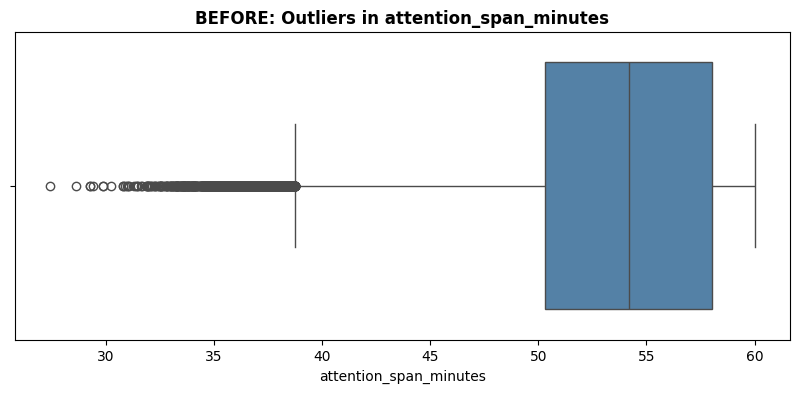

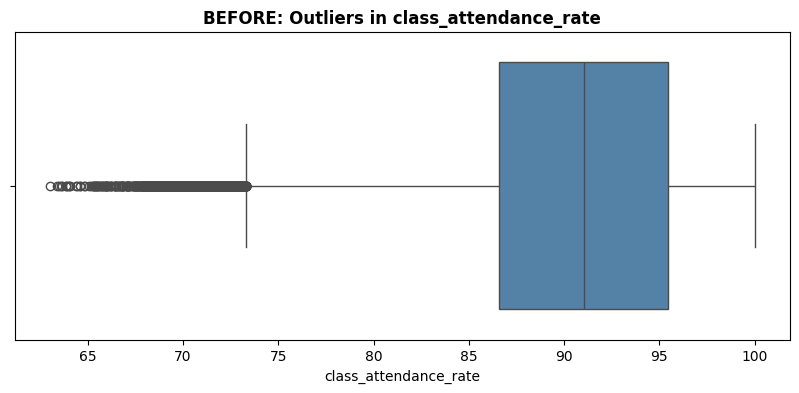


--- COUNTPLOTS ---


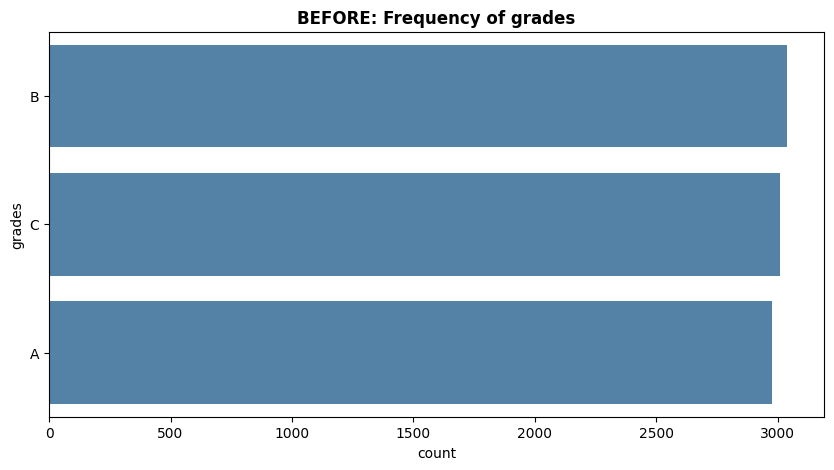

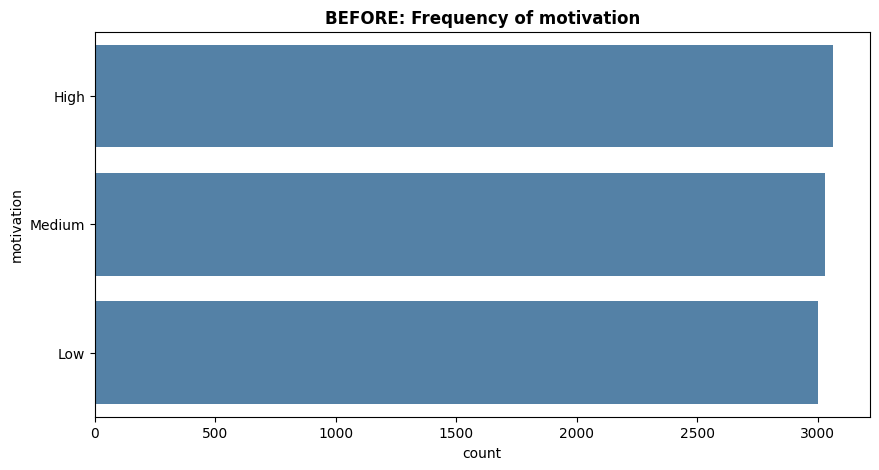

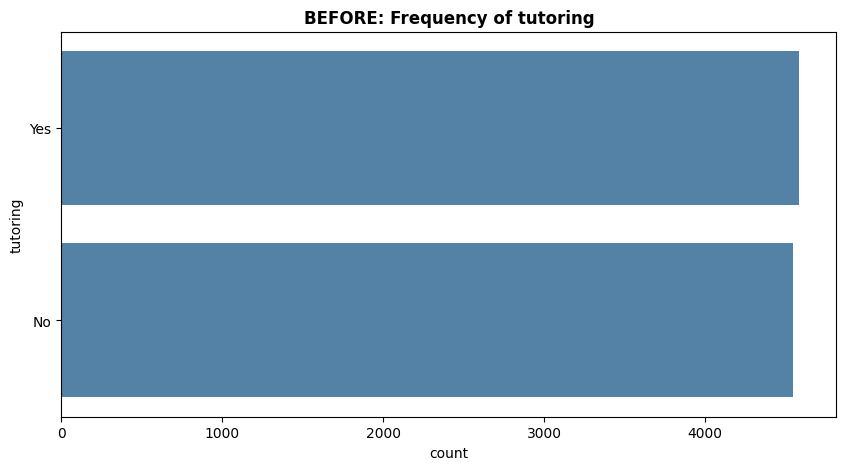


--- BOXPLOTS AFTER CLEANING ---


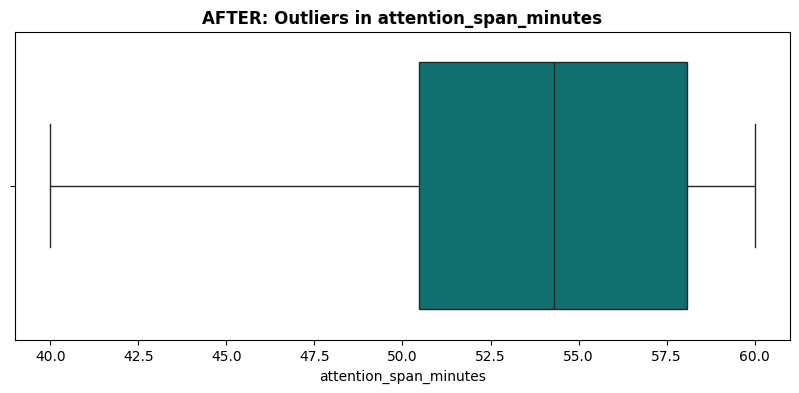

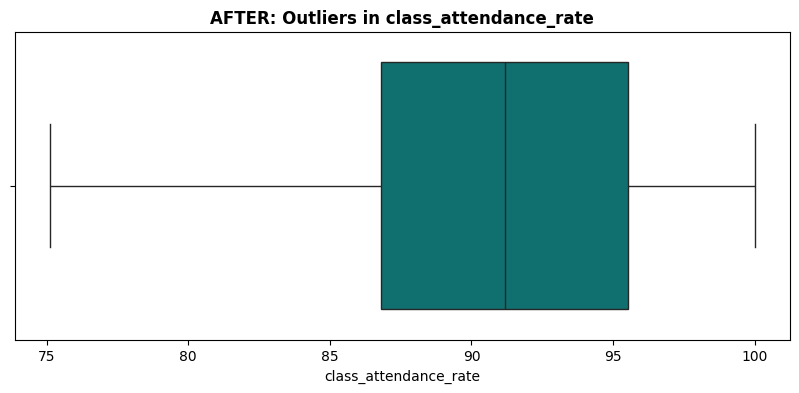


--- COUNTPLOTS AFTER CLEANING ---


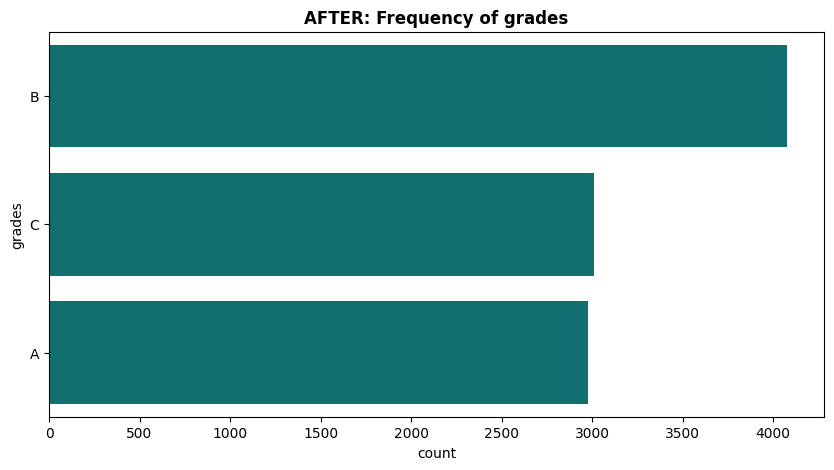

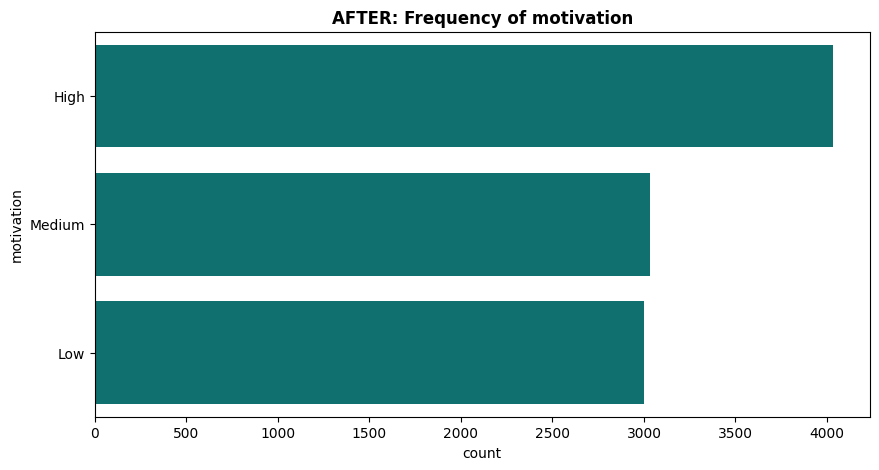

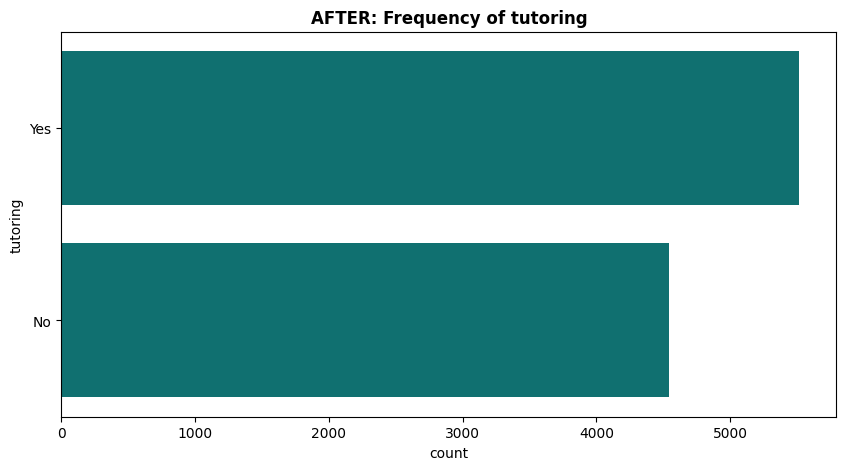



--- NULL COUNTS AFTER CLEANING ---
+----------------------+-------------+
|column_name           |missing_count|
+----------------------+-------------+
|study_hours_per_week  |0            |
|class_attendance_rate |0            |
|productivity_score    |0            |
|attention_span_minutes|0            |
|academic_risk_score   |0            |
|academic_motivation   |0            |
|online_learning_hours |0            |
|attendance            |0            |
|class_participation   |0            |
|grades                |0            |
|motivation            |0            |
|previous_grades       |0            |
|tutoring              |0            |
|educational_resources |0            |
+----------------------+-------------+



In [49]:
# MEMBER 1

m1_df = merged_df

m1_cols = [
    'study_hours_per_week', 'class_attendance_rate', 'productivity_score',
    'attention_span_minutes', 'academic_risk_score', 'academic_motivation',
    'online_learning_hours', 'attendance', 'class_participation',
    'grades', 'motivation', 'previous_grades', 'tutoring', 'educational_resources'
]

# Null count before cleaning
null_counts = merged_df.select([
    F.sum(F.when(F.col(c).isNull(), 1).otherwise(0)).alias(c)
    for c in m1_cols
])

cols_expr = ", ".join([f"'{c}', `{c}`" for c in m1_cols])
print("--- NULL COUNTS BEFORE CLEANING ---")
null_counts.selectExpr(f"stack({len(m1_cols)}, {cols_expr}) as (column_name, missing_count)") \
           .orderBy(F.col('missing_count').desc()) \
           .show(len(m1_cols), truncate=False)


df1_pd = m1_df.filter(F.col('source') == 'df1') \
              .select('study_hours_per_week', 'class_attendance_rate',
                      'productivity_score', 'attention_span_minutes',
                      'academic_risk_score', 'academic_motivation',
                      'online_learning_hours').toPandas()

df2_pd = m1_df.filter(F.col('source') == 'df2') \
              .select('grades', 'motivation', 'tutoring').toPandas()


# Boxplots
print("\n--- BOXPLOTS ---")
for col in ['attention_span_minutes', 'class_attendance_rate']:
    plt.figure(figsize=(10, 4))
    sns.boxplot(data=df1_pd, x=col, color='steelblue')
    plt.title(f'BEFORE: Outliers in {col}', fontweight='bold')
    plt.show()

# Countplots
print("\n--- COUNTPLOTS ---")
for col in ['grades', 'motivation', 'tutoring']:
    plt.figure(figsize=(10, 5))
    order = df2_pd[col].value_counts().index
    sns.countplot(data=df2_pd, y=col, color='steelblue', order=order)
    plt.title(f'BEFORE: Frequency of {col}', fontweight='bold')
    plt.show()


# --- DATA CLEANING SECTION ---
num_cols = [
    'study_hours_per_week', 'class_attendance_rate', 'productivity_score',
    'attention_span_minutes', 'academic_risk_score', 'academic_motivation',
    'online_learning_hours'
]

cat_cols = [
    'grades', 'motivation', 'tutoring', 'previous_grades',
    'attendance', 'class_participation', 'educational_resources'
]


num_medians = {col: m1_df.filter(F.col('source') == 'df1').approxQuantile(col, [0.5], 0.001)[0]
               for col in num_cols}
m1_df = m1_df.fillna(num_medians)

# --- OUTLIER REMOVAL ---
for col_name in ['attention_span_minutes', 'class_attendance_rate']:
    # Get 25th and 75th percentiles
    quants = m1_df.approxQuantile(col_name, [0.25, 0.75], 0.05)
    iqr = quants[1] - quants[0]
    lower_bound = quants[0] - (1.5 * iqr)
    upper_bound = quants[1] + (1.5 * iqr)

    # Filter out the outliers while keeping the values in range
    m1_df = m1_df.filter((F.col(col_name) >= lower_bound) & (F.col(col_name) <= upper_bound))

# Standard logical range filters
m1_df = m1_df.filter(
    (F.col('class_attendance_rate') <= 100) &
    (F.col('study_hours_per_week') >= 0)
)

for col in cat_cols:
    mode_row = m1_df.filter(F.col('source') == 'df2').groupBy(col).count().orderBy('count', ascending=False).first()
    if mode_row and mode_row[0] is not None:
        m1_df = m1_df.fillna({col: mode_row[0]})
    else:
        m1_df = m1_df.fillna({col: "Unknown"})

df1_clean_pd = m1_df.filter(F.col('source') == 'df1') \
                  .select('study_hours_per_week', 'class_attendance_rate',
                          'productivity_score', 'attention_span_minutes',
                          'academic_risk_score').toPandas()

df2_clean_pd = m1_df.filter(F.col('source') == 'df2') \
                  .select('grades', 'motivation', 'tutoring').toPandas()


# Boxplots AFTER
print("\n--- BOXPLOTS AFTER CLEANING ---")
for col in ['attention_span_minutes', 'class_attendance_rate']:
    plt.figure(figsize=(10, 4))
    sns.boxplot(data=df1_clean_pd, x=col, color='teal')
    plt.title(f'AFTER: Outliers in {col}', fontweight='bold')
    plt.show()

# Countplots AFTER
print("\n--- COUNTPLOTS AFTER CLEANING ---")
for col in ['grades', 'motivation', 'tutoring']:
    plt.figure(figsize=(10, 5))
    order = df2_clean_pd[col].value_counts().index
    sns.countplot(data=df2_clean_pd, y=col, color='teal', order=order)
    plt.title(f'AFTER: Frequency of {col}', fontweight='bold')
    plt.show()


m1_cols = [
    'study_hours_per_week', 'class_attendance_rate', 'productivity_score',
    'attention_span_minutes', 'academic_risk_score', 'academic_motivation',
    'online_learning_hours', 'attendance', 'class_participation',
    'grades', 'motivation', 'previous_grades', 'tutoring', 'educational_resources'
]

# Calculate the sums of Nulls for each column in m1_df
null_counts_after = m1_df.select([
    F.sum(F.when(F.col(c).isNull(), 1).otherwise(0)).alias(c)
    for c in m1_cols
])

# Create the expression to "stack" the results vertically
cols_expr = ", ".join([f"'{c}', `{c}`" for c in m1_cols])

print("\n\n--- NULL COUNTS AFTER CLEANING ---")

# Generate and show the vertical summary table
null_counts_after.selectExpr(f"stack({len(m1_cols)}, {cols_expr}) as (column_name, missing_count)") \
                 .orderBy(F.col('missing_count').desc()) \
                 .show(len(m1_cols), truncate=False)

Stress_level column
+-------+------------------+
|summary|      stress_level|
+-------+------------------+
|  count|            507500|
|   mean| 4.851058902012008|
| stddev|1.4894371202314596|
|    min|               1.0|
|    max|            Medium|
+-------+------------------+

Stress Level Null Values: 10064

Stress Level Null Values After Preprocessing: 0


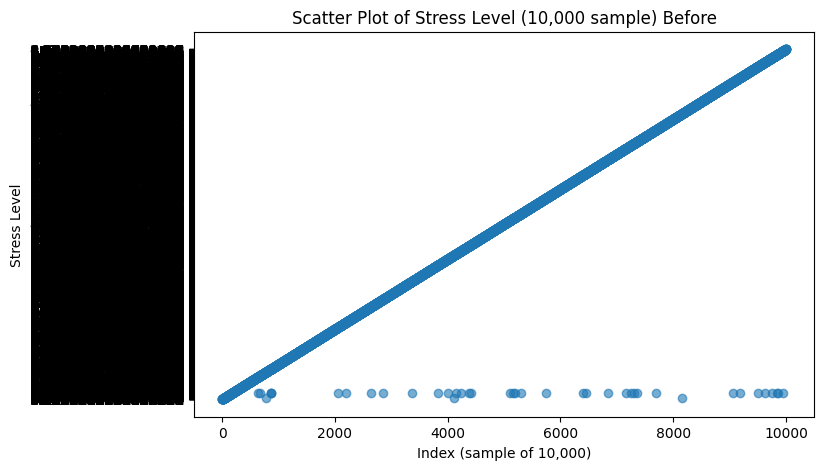

String values in the column
+----------+------------+
|student_id|stress_level|
+----------+------------+
|    500965|        high|
|    500966|      medium|
|    500967|        high|
|    500968|      medium|
|    500969|         low|
|    500970|      medium|
|    500971|        high|
|    500972|      medium|
|    500973|        high|
|    500974|         low|
|    500975|        high|
|    500976|      medium|
|    500977|      medium|
|    500978|         low|
|    500979|         low|
|    500980|         low|
|    500981|        high|
|    500982|         low|
|    500983|        high|
|    500984|      medium|
+----------+------------+
only showing top 20 rows
Stress_level with values low, medium, high
+----------+--------------------+
|student_id|stress_level_convert|
+----------+--------------------+
+----------+--------------------+



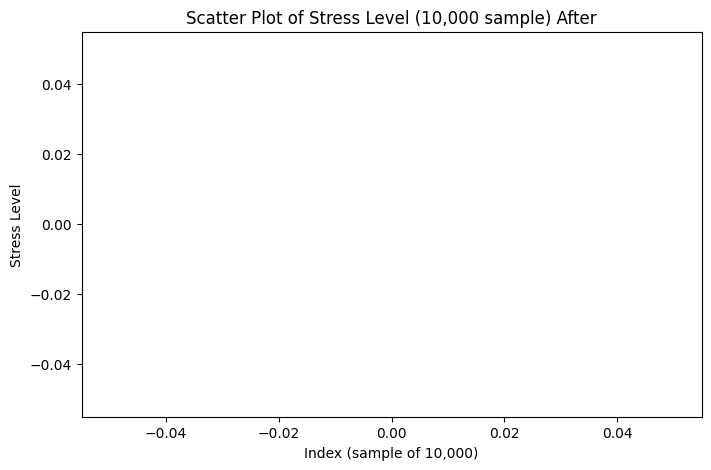

In [ ]:
#MEMBER 2

#describe the column to see the status if what needs to be preprocessed
print("Stress_level column")
df.describe("stress_level").show()


#Now we will count the Null Values
print("Stress Level Null Values:", df.filter(col("stress_level").isNull()).count())

#remove null values
df_stressLevelClean = df.filter(col("stress_level").isNotNull())

print("\nStress Level Null Values After Preprocessing:", df_stressLevelClean.filter(col("stress_level").isNull()).count())


import matplotlib.pyplot as plt

# Limit to 10,000 rows before converting
pdf = df_stressLevelClean.select("stress_level").limit(10000).toPandas()

# Scatter plot: stress_level vs row index
plt.figure(figsize=(8,5))
plt.scatter(pdf.index, pdf["stress_level"], alpha=0.6)
plt.xlabel("Index (sample of 10,000)")
plt.ylabel("Stress Level")
plt.title("Scatter Plot of Stress Level (10,000 sample) Before")
plt.show()

#lowercase
df_lower = df_stressLevelClean.withColumn("stress_level", lower(col("stress_level")))

print("String values in the column")
df_filtered = df_lower.filter(col("stress_level").isin("low", "medium", "high")) \
                      .select("student_id","stress_level")

df_filtered.show()


# since the stress level has a string values we will replace string values with numeric mapping
from pyspark.sql.functions import when, col

# Custom numeric mapping for stress_level
df_mapped = df_lower.withColumn(
    "stress_level_convert",
    when(col("stress_level") == "low", "1")
    .when(col("stress_level") == "medium", "5")
    .when(col("stress_level") == "high", "10")
    .otherwise(None)   # keep None if unexpected category
)

print("Stress_level with values low, medium, high")
df_f = df_mapped.filter(col("stress_level_convert").isin("low", "medium", "high")) \
                      .select("student_id","stress_level_convert")

df_f.show()
df_double = df_mapped.withColumn("stress_level_convert", col("stress_level_convert").cast("double"))

# Limit to 10,000 rows before converting
pdf = df_double.select("stress_level_convert").limit(10000).toPandas()

# Scatter plot: stress_level vs row index
plt.figure(figsize=(8,5))
plt.scatter(pdf.index, pdf["stress_level_convert"], alpha=0.6)
plt.xlabel("Index (sample of 10,000)")
plt.ylabel("Stress Level")
plt.title("Scatter Plot of Stress Level (10,000 sample) After")
plt.show()


In [50]:
#MEMBER 3

from pyspark.sql import SparkSession
from pyspark.sql.types import StructType, StructField, StringType, DoubleType, IntegerType
from pyspark.sql import functions as F
from pyspark.ml.feature import StandardScaler, VectorAssembler
import matplotlib.pyplot as plt

# Initialize SparkSession if it's not already defined (to make cell runnable independently)
# If running the entire notebook in order, this might create a new session or reuse existing one
try:
    spark
except NameError:
    spark = SparkSession.builder.appName('GlobalStudentDigitalBehavior').getOrCreate()

# Schema
schema = StructType([
    StructField("student_id", StringType()),
    StructField("social_media_hours", DoubleType()),
    StructField("sessions_per_day", IntegerType()),
    StructField("average_session_length_minutes", DoubleType()),
    StructField("brain_rot_index", DoubleType()),
    StructField("brain_rot_level", StringType()),
    StructField("short_video_hours", DoubleType()),
    StructField("late_night_usage", StringType()),
    StructField("late_night_score", DoubleType()),
    StructField("digital_addiction_score", DoubleType()),
    StructField("education_content_hours", DoubleType()),
    StructField("entertainment_content_hours", DoubleType())
])

# The dataframe `df` is expected to be loaded from previous cells.
# If this cell needs to be run independently, uncomment the following line and ensure the path is correct.
# df = spark.read.csv("/content/global_student_digital_behavior_dataset_new.csv", header=True, schema=schema)

# Fill missing (mode) for brain_rot_level
mode_val = df.groupBy("brain_rot_level").count().orderBy(F.desc("count")).first()[0]
df = df.fillna({"brain_rot_level": mode_val})

# Clean + encode
df = df.withColumn("brain_rot_level", F.trim(F.lower(F.col("brain_rot_level")))) \
       .withColumn("late_night_usage", F.trim(F.lower(F.col("late_night_usage")))) \
       .withColumn("brain_rot_level_encoded",
            F.when(F.col("brain_rot_level")=="never",0)
            .when(F.col("brain_rot_level")=="low",0) # Added this line to handle 'low' mode
            .when(F.col("brain_rot_level")=="sometimes",1)
            .when(F.col("brain_rot_level")=="often",2)
            .when(F.col("brain_rot_level")=="always",3)
            .otherwise(None)
       ) \
       .withColumn("late_night_usage_encoded",
            F.when(F.col("late_night_usage")=="never",0)
            .when(F.col("late_night_usage")=="sometimes",1)
            .when(F.col("late_night_usage")=="often",2)
            .when(F.col("late_night_usage")=="always",3)
            .otherwise(None)
       )

# Scale
num_cols = [
    "social_media_hours","sessions_per_day","average_session_length_minutes",
    "brain_rot_index","short_video_hours","late_night_score",
    "digital_addiction_score","education_content_hours","entertainment_content_hours", "study_hours"
]

# Fill null values in numeric columns with their respective means
# Calculate means for numeric columns
means = df.select([F.mean(c).alias(c) for c in num_cols]).first().asDict()

# Fill null values in numeric columns with their respective means
for col_name, mean_value in means.items():
    df = df.fillna(mean_value, subset=[col_name])

df_scaled = StandardScaler(inputCol="features", outputCol="scaled", withMean=True, withStd=True) \
    .fit(VectorAssembler(inputCols=num_cols, outputCol="features").transform(df)) \
    .transform(VectorAssembler(inputCols=num_cols, outputCol="features").transform(df))

# BEFORE EDA (last)
pdf_before = df.select("brain_rot_level","social_media_hours").toPandas()
pdf_before["brain_rot_level"].value_counts().plot(kind="bar", title="BEFORE")
plt.show()
pdf_before["social_media_hours"].hist()
plt.title("BEFORE")
plt.show()

# AFTER EDA
pdf_after = df_scaled.select("brain_rot_level_encoded","social_media_hours").toPandas()
pdf_after["brain_rot_level_encoded"].value_counts().plot(kind="bar", title="AFTER")
plt.show()
pdf_after["social_media_hours"].hist()
plt.title("AFTER")
plt.show()

# Output
df_scaled.select("student_id","brain_rot_level_encoded","late_night_usage_encoded","scaled").show(5)

{"ts": "2026-04-20 19:21:04.415", "level": "ERROR", "logger": "DataFrameQueryContextLogger", "msg": "[UNRESOLVED_COLUMN.WITH_SUGGESTION] A column, variable, or function parameter with name `late_night_score` cannot be resolved. Did you mean one of the following? [`late_night_usage`, `anxiety_score`, `depression_score`, `late_night_usage_encoded`, `academic_risk_score`]. SQLSTATE: 42703", "context": {"file": "jdk.internal.reflect.GeneratedMethodAccessor5.invoke(Unknown Source)", "line": "", "fragment": "col", "errorClass": "UNRESOLVED_COLUMN.WITH_SUGGESTION"}, "exception": {"class": "Py4JJavaError", "msg": "An error occurred while calling o13606.select.\n: org.apache.spark.sql.AnalysisException: [UNRESOLVED_COLUMN.WITH_SUGGESTION] A column, variable, or function parameter with name `late_night_score` cannot be resolved. Did you mean one of the following? [`late_night_usage`, `anxiety_score`, `depression_score`, `late_night_usage_encoded`, `academic_risk_score`]. SQLSTATE: 42703;\n'Aggre

AnalysisException: [UNRESOLVED_COLUMN.WITH_SUGGESTION] A column, variable, or function parameter with name `late_night_score` cannot be resolved. Did you mean one of the following? [`late_night_usage`, `anxiety_score`, `depression_score`, `late_night_usage_encoded`, `academic_risk_score`]. SQLSTATE: 42703;
'Aggregate [avg(social_media_hours#1264) AS social_media_hours#19117, avg(sessions_per_day#1265) AS sessions_per_day#19118, avg(average_session_length_minutes#1266) AS average_session_length_minutes#19119, avg(brain_rot_index#1272) AS brain_rot_index#19120, avg(short_video_hours#1270) AS short_video_hours#19121, 'avg('late_night_score) AS late_night_score#19122, avg(digital_addiction_score#1273) AS digital_addiction_score#19123, avg(education_content_hours#1269) AS education_content_hours#19124, avg(entertainment_content_hours#1271) AS entertainment_content_hours#19125, avg(cast(study_hours#1291 as double)) AS study_hours#19126]
+- Project [student_id#1257, age#1258, gender#1259, dev

BEFORE CLEANING
Unique genders in dataset 1: [Row(gender='Female'), Row(gender='Other'), Row(gender='Male')]
Unique genders in dataset 2: [Row(gender='F'), Row(gender='M'), Row(gender=None)]
AFTER CLEANING
Unique genders in dataset 1: [Row(gender_clean='Female'), Row(gender_clean='Other'), Row(gender_clean='Male')]
Unique genders in dataset 2 [Row(gender_clean='Female'), Row(gender_clean='Other'), Row(gender_clean='Male')]


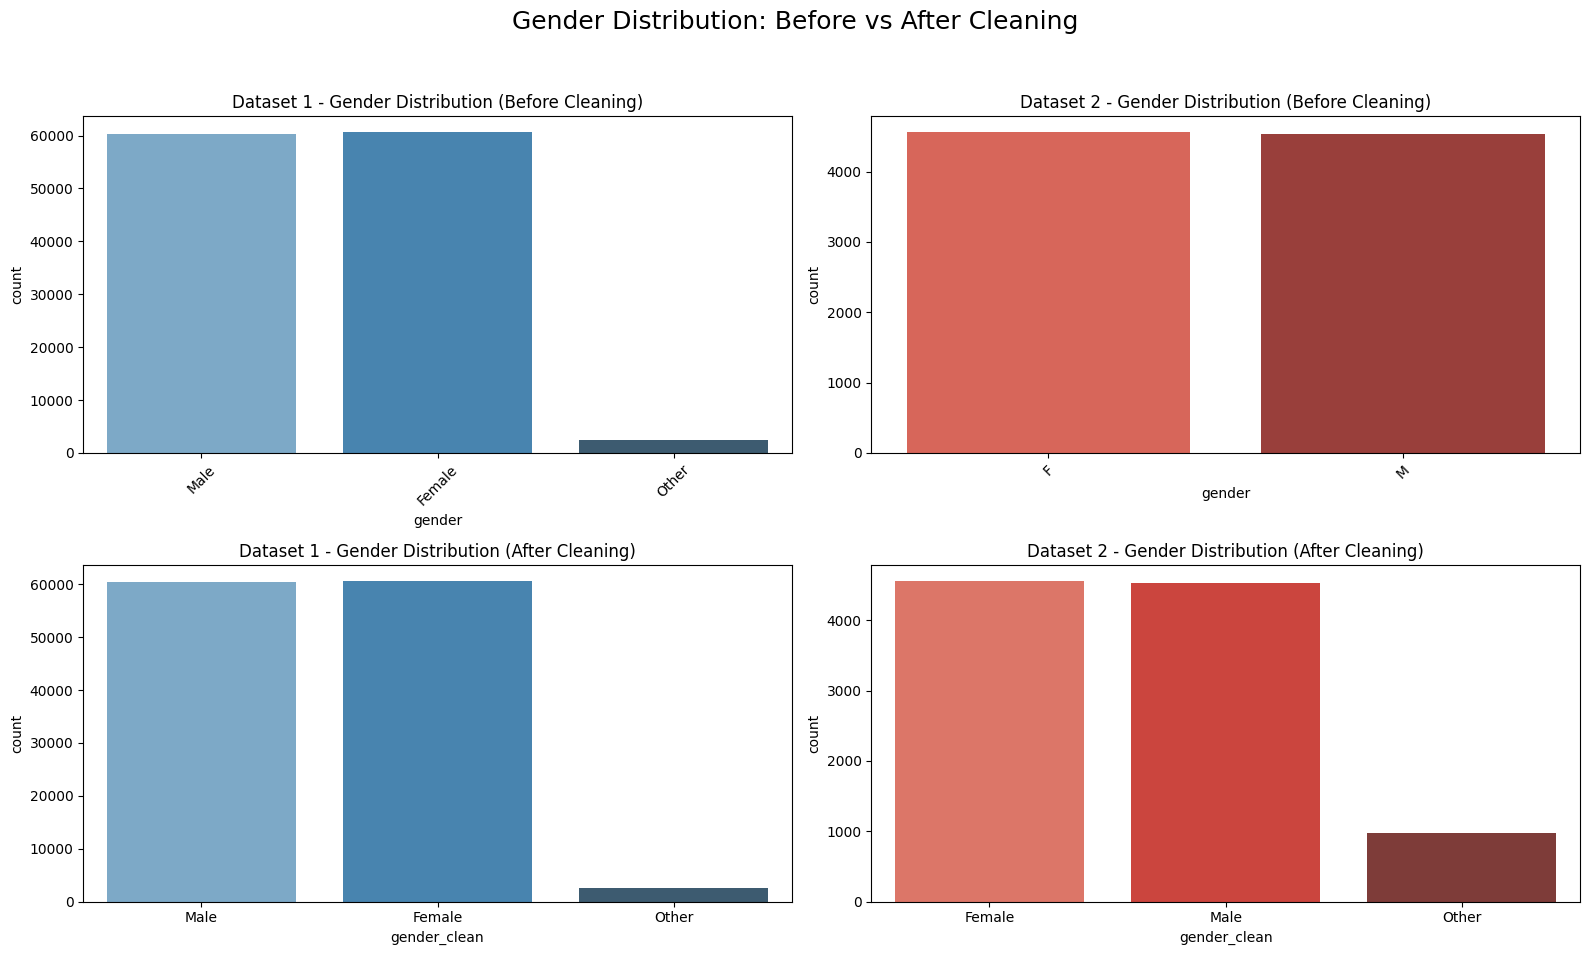

In [ ]:

from pyspark.sql.functions import col

print("BEFORE CLEANING")
print("Unique genders in dataset 1:", df1.select("gender").distinct().collect())
print("Unique genders in dataset 2:", df2.select("gender").distinct().collect())

#convert to Pandas for plotting
pdf1_before = df1.select("gender").toPandas()
pdf2_before = df2.select("gender").toPandas()

#perform cleaning on gender
def clean_gender(df):
    df = df.withColumn("gender_clean",
        when(lower(col("gender")).isin("male", "m", "man", "boy"), "Male")
        .when(lower(col("gender")).isin("female", "f", "woman", "girl"), "Female")
        .when(lower(col("gender")).isin("other", "o", "non-binary", "trans", "prefer not to say"), "Other")
        .otherwise("Other")
    )
    return df

df1_clean = clean_gender(df1)
df2_clean = clean_gender(df2)

print("AFTER CLEANING")
print("Unique genders in dataset 1:", df1_clean.select("gender_clean").distinct().collect())
print("Unique genders in dataset 2", df2_clean.select("gender_clean").distinct().collect())

#convert cleaned data to Pandas
pdf1_after = df1_clean.select("gender_clean").toPandas()
pdf2_after = df2_clean.select("gender_clean").toPandas()

#Creating visualization for before and after data cleaning
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Before Cleaning
sns.countplot(x='gender', data=pdf1_before, ax=axes[0,0], palette='Blues_d', hue='gender', legend=False)
axes[0,0].set_title("Dataset 1 - Gender Distribution (Before Cleaning)")
axes[0,0].tick_params(axis='x', rotation=45)

sns.countplot(x='gender', data=pdf2_before, ax=axes[0,1], palette='Reds_d', hue='gender', legend=False)
axes[0,1].set_title("Dataset 2 - Gender Distribution (Before Cleaning)")
axes[0,1].tick_params(axis='x', rotation=45)

# After Cleaning
sns.countplot(x='gender_clean', data=pdf1_after, ax=axes[1,0], palette='Blues_d', hue='gender_clean', legend=False)
axes[1,0].set_title("Dataset 1 - Gender Distribution (After Cleaning)")
axes[1,0].tick_params(axis='x', rotation=0)

sns.countplot(x='gender_clean', data=pdf2_after, ax=axes[1,1], palette='Reds_d', hue='gender_clean', legend=False)
axes[1,1].set_title("Dataset 2 - Gender Distribution (After Cleaning)")
axes[1,1].tick_params(axis='x', rotation=0)

plt.suptitle("Gender Distribution: Before vs After Cleaning", fontsize=18)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()





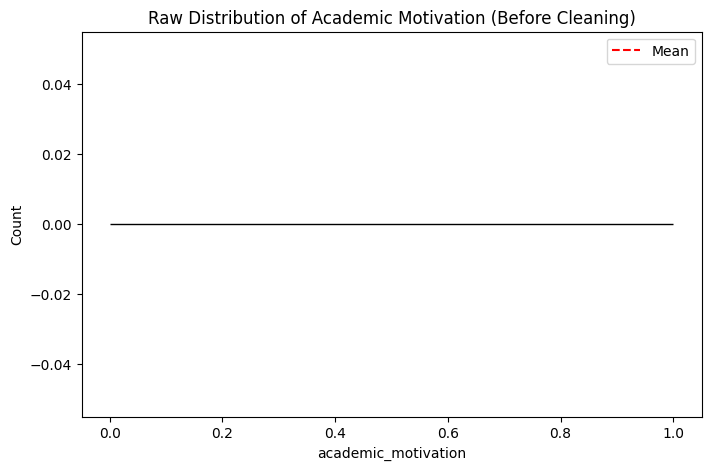

Skewness before: nan


/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:1101: RuntimeWarning: invalid value encountered in divide
  updated_mean = (last_sum + new_sum) / updated_sample_count
/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:1106: RuntimeWarning: invalid value encountered in divide
  T = new_sum / new_sample_count
/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:1126: RuntimeWarning: invalid value encountered in divide
  new_unnormalized_variance -= correction**2 / new_sample_count


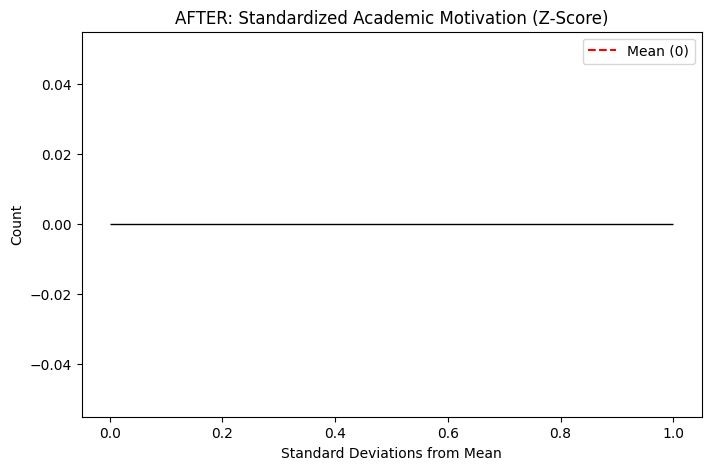

In [51]:
 #MEMBER 4
from pyspark.sql.types import StructType, StructField, IntegerType, DoubleType
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Convert PySpark column to Pandas for plotting
motivation_data = df1.select("academic_motivation").toPandas()

# Graph 1: BEFORE Preprocessing
plt.figure(figsize=(8, 5))
sns.histplot(motivation_data['academic_motivation'], kde=True, color='blue')
plt.axvline(motivation_data['academic_motivation'].mean(), color='red', linestyle='--', label='Mean')
plt.title("Raw Distribution of Academic Motivation (Before Cleaning)")
plt.legend()
plt.show()

print(f"Skewness before: {motivation_data['academic_motivation'].skew()}")

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_values = scaler.fit_transform(motivation_data[['academic_motivation']])
motivation_data['motivation_scaled'] = scaled_values

# Graph 2: AFTER Preprocessing
plt.figure(figsize=(8, 5))
sns.histplot(motivation_data['motivation_scaled'], kde=True, color='green')
plt.axvline(motivation_data['motivation_scaled'].mean(), color='red', linestyle='--', label='Mean (0)')
plt.title("AFTER: Standardized Academic Motivation (Z-Score)")
plt.xlabel("Standard Deviations from Mean")
plt.legend()
plt.show()


